In [2]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector, partial_trace, entropy
from qiskit.circuit.library import RXGate
import matplotlib.pyplot as plt

# ---------------- Node ordering ----------------
def node_order_by_cost_degree(G, C):
    """
    Order nodes by descending cost and then descending degree.
    """
    return sorted(G.nodes(), key=lambda i: (-C[i], G.degree(i)))

# ---------------- Mixer circuit ----------------
def mixer_from_graph(G, c, p=3,node_order=None):
    """
    Build one-layer constrained mixer circuit.
    """
    G = nx.convert_node_labels_to_integers(G)
    n = G.number_of_nodes()

    qc = QuantumCircuit(n)
    betas = {i: Parameter(f"β_{i}") for i in G.nodes()}

    # Start in all-1 state (all vertices in cover)
    for i in range(n):
        qc.x(i)

    if node_order is None:
        node_order = node_order_by_cost_degree(G, c)
    for _ in range (p):
        for tgt in node_order:
            angle = 2 * betas[tgt]/p
            ctrls = list(G.neighbors(tgt))
            if ctrls:
                qc.append(RXGate(angle).control(len(ctrls)), ctrls + [tgt])
            else:
                qc.rx(angle, tgt)

    return qc, betas, G

# ---------------- Entanglement entropy ----------------
def compute_entropy(qc, subsys, param_values):
    """Compute von Neumann entropy of a qubit subset."""
    sv = Statevector.from_instruction(qc.assign_parameters(param_values))
    n = qc.num_qubits
    complement = [i for i in range(n) if i not in subsys]
    rho_sub = partial_trace(sv, complement)
    #print(f"Entropy for subsys {subsys}:{entropy(rho_sub, base=2)}")
    return entropy(rho_sub, base=2)


# ---------------- Entanglement profile for up to n/2 ----------------
def entanglement_profile(G, c, param_value=np.pi/4):
    """
    Compute von Neumann entanglement entropy for single qubits
    and contiguous blocks up to half the system size.
    """
    qc, betas, _ = mixer_from_graph(G, c)
    param_values = {p: param_value for p in qc.parameters}
    n = qc.num_qubits

    # Single-qubit entanglement
    S_single = [compute_entropy(qc, [i], param_values) for i in range(n)]

    # Contiguous block entanglement (up to n//2)
    max_block = n // 2
    S_blocks = [compute_entropy(qc, list(range(k)), param_values) for k in range(1, max_block + 1)]

    return S_single, S_blocks

# ---------------- Plotting function ----------------
def plot_entanglement(S_single, S_blocks):
    plt.figure(figsize=(10,4))

    # Single-qubit entanglement
    plt.subplot(1,2,1)
    plt.bar(range(len(S_single)), S_single)
    plt.xlabel("Qubit index")
    plt.ylabel("S({i}) [bits]")
    plt.title("Single-qubit entanglement")

    # Block entanglement
    plt.subplot(1,2,2)
    plt.plot(range(1, len(S_blocks)+1), S_blocks, marker='o')
    plt.xlabel("Block size k")
    plt.ylabel("S({0,...,k-1}) [bits]")
    plt.title("Contiguous block entanglement")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

import random

def entanglement_profile_random_blocks(G, c, param_value=np.pi/4, num_samples=50):
    """
    Compute entanglement profile for random qubit blocks of varying size.
    
    Args:
        G: NetworkX graph
        c: vertex costs
        param_value: value for all beta parameters
        num_samples: number of random blocks to average over
    Returns:
        S_single: list of single-qubit entropies
        S_mean: list of mean entropy for block sizes 1..n
        S_var: list of variance of entropy for block sizes 1..n
    """
    qc, betas, _ = mixer_from_graph(G, c)
    param_values = {p: param_value for p in qc.parameters}
    n = qc.num_qubits

    # Single-qubit entanglement
    S_single = [compute_entropy(qc, [i], param_values) for i in range(n)]
    max_block = n // 2
    # Random block entanglement
    S_mean = []
    S_var = []
    for k in range(1, max_block +1):
        samples = []
        for _ in range(num_samples):
            block = random.sample(range(n), k)
            samples.append(compute_entropy(qc, block, param_values))
        S_mean.append(np.mean(samples))
        S_var.append(np.var(samples))

    return S_single, S_mean, S_var
def plot_entanglement_random_blocks(S_single, S_mean, S_var):
    plt.figure(figsize=(10,4))

    # Single-qubit entanglement
    plt.subplot(1,2,1)
    plt.bar(range(len(S_single)), S_single)
    plt.xlabel("Qubit index")
    plt.ylabel("S({i}) [bits]")
    plt.title("Single-qubit entanglement")

    # Random block entanglement with error bars
    plt.subplot(1,2,2)
    S_std = np.sqrt(S_var)
    plt.errorbar(range(1, len(S_mean)+1), S_mean, yerr=S_std, fmt='o-', capsize=5)
    plt.xlabel("Block size k")
    plt.ylabel("Mean S(random block) [bits]")
    plt.title("Random block entanglement")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Compute entanglement over multiple random graphs ----------------
def entanglement_vs_size_avg(graph_sizes, degree=3, param_value=np.pi/4, 
                             num_blocks=10, num_graphs=5, graph_type="regular"):
    """
    Compute random-block entanglement mean and std over multiple graphs.
    """
    all_mean_blocks = []  # mean over graphs
    all_std_blocks = []   # std over graphs

    for n in graph_sizes:
        print(n)
        block_entanglements = []

        for g_idx in range(num_graphs):
            print(g_idx)
            # Generate a connected graph
            connected = False
            while not connected:
                if graph_type == "erdos":
                    G = nx.erdos_renyi_graph(n, degree/10)
                else:
                    G = nx.random_regular_graph(degree, n)
                connected = nx.is_connected(G)

            # Assign uniform costs
            c = {i: 1 for i in G.nodes()}

            # Compute entanglement with random blocks
            S_single, S_blocks_mean, S_blocks_var = entanglement_profile_random_blocks(
                G, c, param_value=param_value, num_samples=num_blocks
            )
            block_entanglements.append(S_blocks_mean)

        # Convert to numpy array to compute mean and std across graphs
        block_entanglements = np.array(block_entanglements)
        all_mean_blocks.append(block_entanglements.mean(axis=0))
        all_std_blocks.append(block_entanglements.std(axis=0))

    return all_mean_blocks, all_std_blocks

# ---------------- Plotting function ----------------
def plot_entanglement_scaling_avg(graph_sizes, all_mean_blocks, all_std_blocks):
    plt.figure(figsize=(8,5))
    
    for i, n in enumerate(graph_sizes):
        mean = all_mean_blocks[i]
        std = all_std_blocks[i]
        plt.errorbar(range(1, len(mean)+1), mean, yerr=std, fmt='o-', capsize=3, label=f'n={n}')
    
    plt.xlabel("A")
    plt.ylabel("S_A")
    plt.grid(True)
    plt.legend()
    plt.show()




In [17]:
# ---------------- Example usage ----------------
graph_sizes = [6,8,10,12,14,16]
graph_type='regular'
degree=3
all_mean_blocks, all_std_blocks = entanglement_vs_size_avg(graph_sizes, degree=3, param_value=np.pi/2,num_blocks=10, num_graphs=10,graph_type='regular')
plot_entanglement_scaling_avg(graph_sizes, all_mean_blocks, all_std_blocks)

6
0
1
2
3
4
5
6
7
8
9
8
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
12
0
1
2
3
4
5
6
7
8
9
14
0
1
2
3
4
5
6
7
8
9
16
0


KeyboardInterrupt: 

In [7]:

last_size = graph_sizes[-1]


filename = (
    f"entanglement_scaling_"
    f"{graph_type}_"
    f"deg{degree}_"
    f"N{last_size}.npz"
)


def save_entanglement_results(filename, graph_sizes, all_mean_blocks, all_std_blocks):
    np.savez(
        filename,
        graph_sizes=np.array(graph_sizes),
        all_mean_blocks=np.array(all_mean_blocks, dtype=object),
        all_std_blocks=np.array(all_std_blocks, dtype=object),
    )

In [8]:
save_entanglement_results(
    filename,
    graph_sizes,
    all_mean_blocks,
    all_std_blocks
)

In [2]:
# ---------------- Entanglement vs number of layers ----------------
def entanglement_vs_layers(
    n=10,
    degree=3,
    p_list=[1,2,3,4],
    param_value=np.pi/4,
    num_blocks=50,
    graph_type="regular"
):
    """
    Fix graph size n and vary number of mixer layers p.
    Returns mean and variance of random block entanglement
    for each layer depth.
    """

    # ----- Generate ONE fixed connected graph -----
    connected = False
    while not connected:
        if graph_type == "erdos":
            G = nx.erdos_renyi_graph(n, degree/10)
        else:
            G = nx.random_regular_graph(degree, n)
        connected = nx.is_connected(G)

    c = {i: 1 for i in G.nodes()}

    all_mean_blocks = []
    all_var_blocks = []

    for p in p_list:
        print(f"Computing for p = {p}")

        # build mixer with depth p
        qc, betas, _ = mixer_from_graph(G, c, p=p)

        param_values = {param: param_value for param in qc.parameters}

        max_block = n // 2
        S_mean = []
        S_var = []

        for k in range(1, max_block + 1):
            samples = []
            for _ in range(num_blocks):
                block = random.sample(range(n), k)
                samples.append(compute_entropy(qc, block, param_values))

            S_mean.append(np.mean(samples))
            S_var.append(np.var(samples))

        all_mean_blocks.append(S_mean)
        all_var_blocks.append(S_var)

    return p_list, all_mean_blocks, all_var_blocks

In [3]:
def plot_entanglement_vs_layers(p_list, all_mean_blocks, all_var_blocks):
    plt.figure(figsize=(8,5))

    for i, p in enumerate(p_list):
        mean = all_mean_blocks[i]
        std = np.sqrt(all_var_blocks[i])

        plt.errorbar(
            range(1, len(mean)+1),
            mean,
            yerr=std,
            fmt='o-',
            capsize=3,
            label=f'p={p}'
        )

    plt.xlabel("Block size |A|")
    plt.ylabel("S_A (random blocks)")
    plt.title("Entanglement growth vs circuit depth (n=10)")
    plt.grid(True)
    plt.legend()
    plt.show()

Computing for p = 1
Computing for p = 2
Computing for p = 3
Computing for p = 4
Computing for p = 5
Computing for p = 6


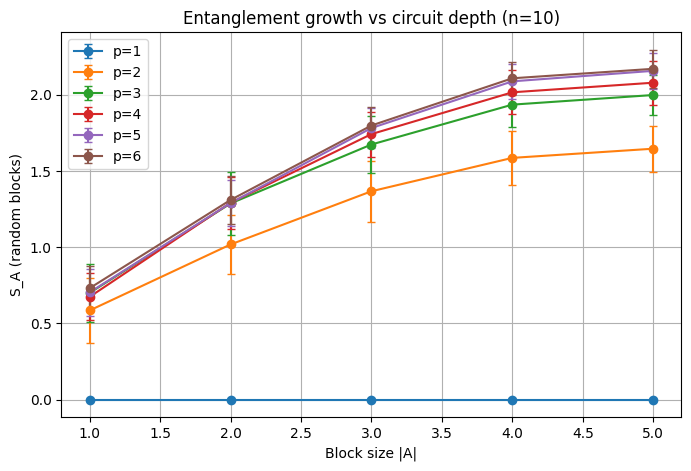

In [16]:
p_list, means, vars_ = entanglement_vs_layers(
    n=10,
    degree=3,
    p_list=[1,2,3,4,5,6],
    param_value=np.pi/2,
    num_blocks=50
)

plot_entanglement_vs_layers(p_list, means, vars_)

In [2]:
def entanglement_half_block_vs_beta_multiple_sizes_avg_graphs(
    sizes,
    p=2,
    degree=3,
    beta_values=None,
    num_blocks=50,
    num_graphs=5,
    graph_type="regular"
):
    """
    For multiple system sizes:
    - Fix p
    - Sweep beta
    - Compute half-system entropy
    - Average over multiple graph realizations
    """

    if beta_values is None:
        beta_values = np.linspace(0, np.pi/2, 20)

    results_mean = {}
    results_std = {}

    for n in sizes:
        print(f"\nProcessing n = {n}")

        half_size = n // 2
        graph_data = []

        for g_idx in range(num_graphs):
            print(f"  Graph {g_idx+1}/{num_graphs}")

            # ---- generate connected graph ----
            connected = False
            while not connected:
                if graph_type == "erdos":
                    G = nx.erdos_renyi_graph(n, degree/10)
                else:
                    G = nx.random_regular_graph(degree, n)
                connected = nx.is_connected(G)

            c = {i: 1 for i in G.nodes()}
            qc, betas, _ = mixer_from_graph(G, c, p=p)

            # Pre-generate half blocks for this graph
            blocks = [random.sample(range(n), half_size) for _ in range(num_blocks)]

            entropies = []

            for beta in beta_values:
                param_values = {param: beta for param in qc.parameters}

                samples = []
                for block in blocks:
                    samples.append(compute_entropy(qc, block, param_values))

                entropies.append(np.mean(samples))

            graph_data.append(entropies)

        # Convert to numpy array: shape (num_graphs, len(beta_values))
        graph_data = np.array(graph_data)

        results_mean[n] = graph_data.mean(axis=0)
        results_std[n] = graph_data.std(axis=0)

    return beta_values, results_mean, results_std

In [3]:
def plot_half_block_multiple_sizes_avg(beta_values, results_mean, results_std):
    plt.figure(figsize=(8,5))

    for n in results_mean:
        mean = results_mean[n]
        std = results_std[n]

        plt.errorbar(
            beta_values,
            mean,
            yerr=std,
            fmt='o-',
            capsize=3,
            label=f'n={n}'
        )

    plt.xlabel("β")
    plt.ylabel("S(|A| = n/2)")
    plt.title("Half-system entanglement vs β (avg over graphs)")
    plt.grid(True)
    plt.legend()
    plt.show()


Processing n = 6
  Graph 1/10
  Graph 2/10
  Graph 3/10
  Graph 4/10
  Graph 5/10
  Graph 6/10
  Graph 7/10
  Graph 8/10
  Graph 9/10
  Graph 10/10

Processing n = 8
  Graph 1/10
  Graph 2/10
  Graph 3/10
  Graph 4/10
  Graph 5/10
  Graph 6/10
  Graph 7/10
  Graph 8/10
  Graph 9/10
  Graph 10/10

Processing n = 10
  Graph 1/10
  Graph 2/10
  Graph 3/10
  Graph 4/10
  Graph 5/10
  Graph 6/10
  Graph 7/10
  Graph 8/10
  Graph 9/10
  Graph 10/10

Processing n = 12
  Graph 1/10
  Graph 2/10
  Graph 3/10
  Graph 4/10
  Graph 5/10
  Graph 6/10
  Graph 7/10
  Graph 8/10
  Graph 9/10
  Graph 10/10

Processing n = 14
  Graph 1/10
  Graph 2/10
  Graph 3/10
  Graph 4/10
  Graph 5/10
  Graph 6/10
  Graph 7/10
  Graph 8/10
  Graph 9/10
  Graph 10/10

Processing n = 16
  Graph 1/10
  Graph 2/10
  Graph 3/10
  Graph 4/10
  Graph 5/10
  Graph 6/10
  Graph 7/10
  Graph 8/10
  Graph 9/10
  Graph 10/10

Processing n = 18
  Graph 1/10
  Graph 2/10
  Graph 3/10
  Graph 4/10
  Graph 5/10
  Graph 6/10
  Gra

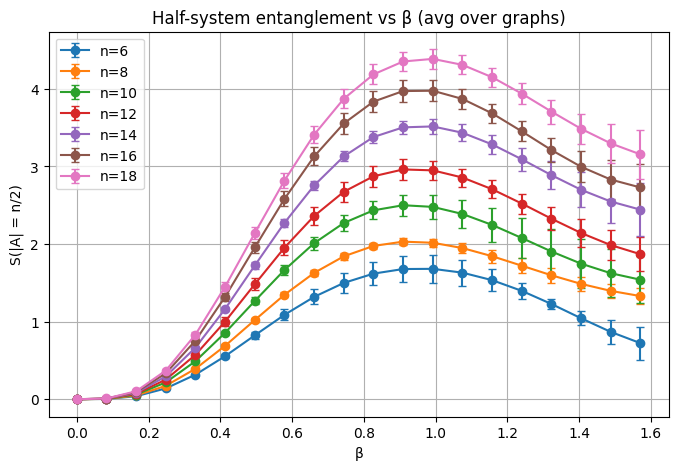

In [11]:
sizes = [6, 8, 10, 12,14,16,18]

beta_vals, mean_results, std_results = entanglement_half_block_vs_beta_multiple_sizes_avg_graphs(
    sizes=sizes,
    p=2,
    degree=3,
    num_blocks=10,
    num_graphs=10
)

plot_half_block_multiple_sizes_avg(beta_vals, mean_results, std_results)

In [5]:
def entanglement_half_block_vs_beta_multiple_p_avg_graphs(
    n=10,
    p_list=[1,2,3,4],
    degree=3,
    beta_values=None,
    num_blocks=10,
    num_graphs=10,
    graph_type="regular"
):
    """
    Fix n.
    Sweep beta.
    Compare multiple p.
    Average over multiple graph realizations.
    """

    if beta_values is None:
        beta_values = np.linspace(0, np.pi/2, 10)

    half_size = n // 2

    # Storage: per p, accumulate results over graphs
    results_mean = {p: [] for p in p_list}
    results_std = {p: [] for p in p_list}

    # We accumulate raw data first
    raw_data = {p: [] for p in p_list}

    for g_idx in range(num_graphs):
        print(f"\nGraph realization {g_idx+1}/{num_graphs}")

        # ---- generate ONE connected graph ----
        connected = False
        while not connected:
            if graph_type == "erdos":
                G = nx.erdos_renyi_graph(n, degree/10)
            else:
                G = nx.random_regular_graph(degree, n)
            connected = nx.is_connected(G)

        c = {i: 1 for i in G.nodes()}

        # Pre-generate half blocks for THIS graph
        blocks = [random.sample(range(n), half_size) for _ in range(num_blocks)]

        for p in p_list:
            qc, betas, _ = mixer_from_graph(G, c, p=p)

            entropies = []

            for beta in beta_values:
                param_values = {param: beta for param in qc.parameters}

                samples = []
                for block in blocks:
                    samples.append(compute_entropy(qc, block, param_values))

                entropies.append(np.mean(samples))

            raw_data[p].append(entropies)

    # ---- Compute mean and std across graphs ----
    for p in p_list:
        data = np.array(raw_data[p])  # shape: (num_graphs, len(beta_values))
        results_mean[p] = data.mean(axis=0)
        results_std[p] = data.std(axis=0)

    return beta_values, results_mean, results_std

In [6]:
def plot_half_block_multiple_p_avg(beta_values, results_mean, results_std):
    plt.figure(figsize=(8,5))

    for p in results_mean:
        mean = results_mean[p]
        std = results_std[p]

        plt.errorbar(
            beta_values,
            mean,
            yerr=std,
            fmt='o-',
            capsize=3,
            label=f'p={p}'
        )

    plt.xlabel("β")
    plt.ylabel("S(|A| = n/2)")
    plt.title("Half-system entanglement vs β (avg over graphs)")
    plt.grid(True)
    plt.legend()
    plt.show()


Graph realization 1/10

Graph realization 2/10

Graph realization 3/10

Graph realization 4/10

Graph realization 5/10

Graph realization 6/10

Graph realization 7/10

Graph realization 8/10

Graph realization 9/10

Graph realization 10/10


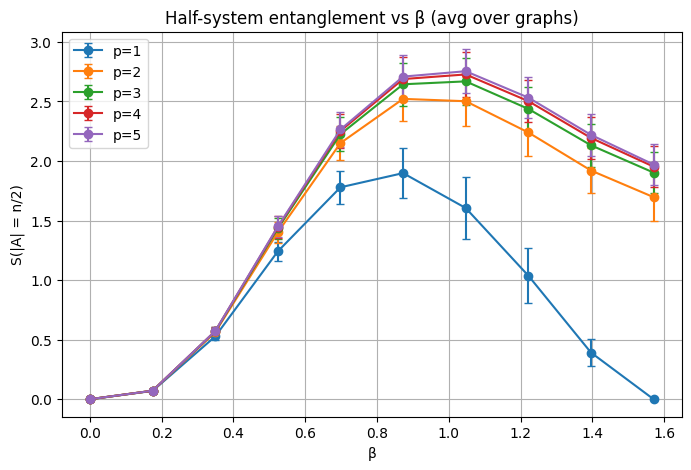

In [7]:
beta_vals, mean_results, std_results = entanglement_half_block_vs_beta_multiple_p_avg_graphs(
    n=10,
    p_list=[1,2,3,4,5],
    degree=3,
    num_blocks=10,
    num_graphs=10
)

plot_half_block_multiple_p_avg(beta_vals, mean_results, std_results)

In [12]:
def entanglement_vs_blocksize_multiple_sizes_avg_graphs(
    sizes,
    p=3,
    alpha=np.pi/4,
    degree=3,
    num_blocks=50,
    num_graphs=5,
    graph_type="regular"
):
    """
    Fix p and alpha.
    For multiple graph sizes:
        compute entropy vs block size
    Average over graph realizations.
    """

    results_mean = {}
    results_std = {}

    for n in sizes:
        print(f"\nProcessing n = {n}")

        max_block = n // 2
        graph_data = []

        for g_idx in range(num_graphs):
            print(f"  Graph {g_idx+1}/{num_graphs}")

            # Generate connected graph
            connected = False
            while not connected:
                if graph_type == "erdos":
                    G = nx.erdos_renyi_graph(n, degree/10)
                else:
                    G = nx.random_regular_graph(degree, n)
                connected = nx.is_connected(G)

            c = {i: 1 for i in G.nodes()}
            qc, alphas, _ = mixer_from_graph(G, c, p=p)

            param_values = {param: alpha for param in qc.parameters}

            block_entropies = []

            for k in range(1, max_block + 1):

                samples = []
                for _ in range(num_blocks):
                    block = random.sample(range(n), k)
                    samples.append(compute_entropy(qc, block, param_values))

                block_entropies.append(np.mean(samples))

            graph_data.append(block_entropies)

        graph_data = np.array(graph_data)

        results_mean[n] = graph_data.mean(axis=0)
        results_std[n] = graph_data.std(axis=0)

    return results_mean, results_std

In [13]:
def plot_entropy_vs_blocksize_multiple_sizes(results_mean, results_std):
    plt.figure(figsize=(8,5))

    for n in results_mean:
        x_vals = range(1, len(results_mean[n]) + 1)
        mean = results_mean[n]
        std = results_std[n]

        plt.errorbar(
            x_vals,
            mean,
            yerr=std,
            fmt='o-',
            capsize=3,
            label=f'n={n}'
        )

    plt.xlabel("Block size |A|")
    plt.ylabel("S_A")
    plt.title("Entanglement vs block size (fixed p and α)")
    plt.grid(True)
    plt.legend()
    plt.show()


Processing n = 6
  Graph 1/10
  Graph 2/10
  Graph 3/10
  Graph 4/10
  Graph 5/10
  Graph 6/10
  Graph 7/10
  Graph 8/10
  Graph 9/10
  Graph 10/10

Processing n = 8
  Graph 1/10
  Graph 2/10
  Graph 3/10
  Graph 4/10
  Graph 5/10
  Graph 6/10
  Graph 7/10
  Graph 8/10
  Graph 9/10
  Graph 10/10

Processing n = 10
  Graph 1/10
  Graph 2/10
  Graph 3/10
  Graph 4/10
  Graph 5/10
  Graph 6/10
  Graph 7/10
  Graph 8/10
  Graph 9/10
  Graph 10/10

Processing n = 12
  Graph 1/10
  Graph 2/10
  Graph 3/10
  Graph 4/10
  Graph 5/10
  Graph 6/10
  Graph 7/10
  Graph 8/10
  Graph 9/10
  Graph 10/10

Processing n = 14
  Graph 1/10
  Graph 2/10
  Graph 3/10
  Graph 4/10
  Graph 5/10
  Graph 6/10
  Graph 7/10
  Graph 8/10
  Graph 9/10
  Graph 10/10

Processing n = 16
  Graph 1/10
  Graph 2/10
  Graph 3/10
  Graph 4/10
  Graph 5/10
  Graph 6/10
  Graph 7/10
  Graph 8/10
  Graph 9/10
  Graph 10/10

Processing n = 18
  Graph 1/10
  Graph 2/10
  Graph 3/10
  Graph 4/10
  Graph 5/10
  Graph 6/10
  Gra

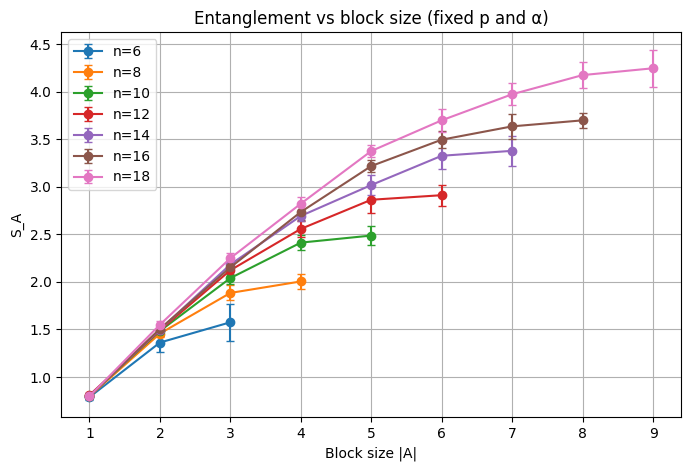

In [14]:
sizes = [6, 8, 10, 12,14,16,18]

mean_results, std_results = entanglement_vs_blocksize_multiple_sizes_avg_graphs(
    sizes=sizes,
    p=3,
    alpha=np.pi/4,
    degree=3,
    num_blocks=10,
    num_graphs=10
)

plot_entropy_vs_blocksize_multiple_sizes(mean_results, std_results)

In [1]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt

def entanglement_vs_size_fixed_beta(
    sizes,
    beta=np.pi/4,
    p=3,
    degree=3,
    num_blocks=50,
    num_graphs=5,
    graph_type="regular"
):
    """
    Compute half-system entropy vs system size at fixed beta.

    x-axis : system size n
    y-axis : average half-system entropy

    Averaged over:
        - random graph realizations
        - random half partitions
    """

    results_mean = []
    results_std = []

    for n in sizes:
        print(f"\nProcessing n = {n}")
        half_size = n // 2

        graph_entropies = []

        for g_idx in range(num_graphs):
            print(f"  Graph {g_idx+1}/{num_graphs}")

            # ---- generate connected graph ----
            connected = False
            while not connected:
                if graph_type == "erdos":
                    G = nx.erdos_renyi_graph(n, degree/10)
                else:
                    G = nx.random_regular_graph(degree, n)
                connected = nx.is_connected(G)

            c = {i: 1 for i in G.nodes()}
            qc, betas, _ = mixer_from_graph(G, c, p=p)

            param_values = {param: beta for param in qc.parameters}

            # random half-system blocks
            blocks = [
                random.sample(range(n), half_size)
                for _ in range(num_blocks)
            ]

            block_entropies = [
                compute_entropy(qc, block, param_values)
                for block in blocks
            ]

            graph_entropies.append(np.mean(block_entropies))

        graph_entropies = np.array(graph_entropies)

        results_mean.append(graph_entropies.mean())
        results_std.append(graph_entropies.std())

    return np.array(sizes), np.array(results_mean), np.array(results_std)

In [ ]:
sizes, mean_S, std_S = entanglement_vs_size_fixed_beta(
    sizes=[6, 8, 10, 12, 14,16,18,20],
    beta=np.pi/4,
    p=3,
    degree=3,
    num_blocks=20,
    num_graphs=5
)

plt.figure(figsize=(6,4))
plt.errorbar(sizes, mean_S, yerr=std_S, marker='o', capsize=4)

plt.xlabel("System size n")
plt.ylabel("S_A (|A|=n/2)")
plt.title(r"Entropy scaling at $\beta=\pi/4$")
plt.grid(True)
plt.show()


Processing n = 6
  Graph 1/5
  Graph 2/5
  Graph 3/5
  Graph 4/5
  Graph 5/5

Processing n = 8
  Graph 1/5
  Graph 2/5
  Graph 3/5
  Graph 4/5
  Graph 5/5

Processing n = 10
  Graph 1/5
  Graph 2/5
  Graph 3/5
  Graph 4/5
  Graph 5/5

Processing n = 12
  Graph 1/5
  Graph 2/5
  Graph 3/5
  Graph 4/5
  Graph 5/5

Processing n = 14
  Graph 1/5
  Graph 2/5
  Graph 3/5
  Graph 4/5
  Graph 5/5

Processing n = 16
  Graph 1/5
  Graph 2/5
  Graph 3/5
  Graph 4/5
  Graph 5/5

Processing n = 18
  Graph 1/5
  Graph 2/5
  Graph 3/5
  Graph 4/5
